In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

In [58]:
# Si tu pars de ta fonction existante :
from data_processing import build_processed_dataframe

DEFAULT_TEXT_COLUMNS = [
    "id",
    "text",
    "date",
    "contexte-tour",
    "departement",
    "identifiant de circonscription",
    "titulaire-sexe",
    "titulaire-mandat-en-cours",
    "titulaire-mandat-passe",
    "titulaire-soutien",
]

df = build_processed_dataframe(
    base_dir="data",
    candidate_file="archelect_search.csv",
    selected_columns=DEFAULT_TEXT_COLUMNS,
    soutien_mapping_csv="data/partis_correspondance.csv",
    mandat_mapping_csv="data/mandats_correspondance.csv",
)

In [59]:
df["n_chars"] = df["text"].str.len()
df["n_words_raw"] = df["text"].str.split().str.len()

print("Nombre de textes :", len(df))
print("Nombre de mots total :", df["n_words_raw"].sum())
print("Longueur moyenne :", round(df["n_words_raw"].mean(), 1))
print("Longueur médiane :", round(df["n_words_raw"].median(), 1))

df[["n_chars", "n_words_raw"]].describe()

Nombre de textes : 21167
Nombre de mots total : 14643498
Longueur moyenne : 691.8
Longueur médiane : 618.0


,n_chars,n_words_raw
count,21167.000000,21167.000000
mean,4370.200831,691.807909
std,2287.057132,363.217882
min,84.000000,10.000000
25%,2680.000000,422.000000
50%,3928.000000,618.000000
75%,5661.000000,896.000000
max,24916.000000,3919.000000


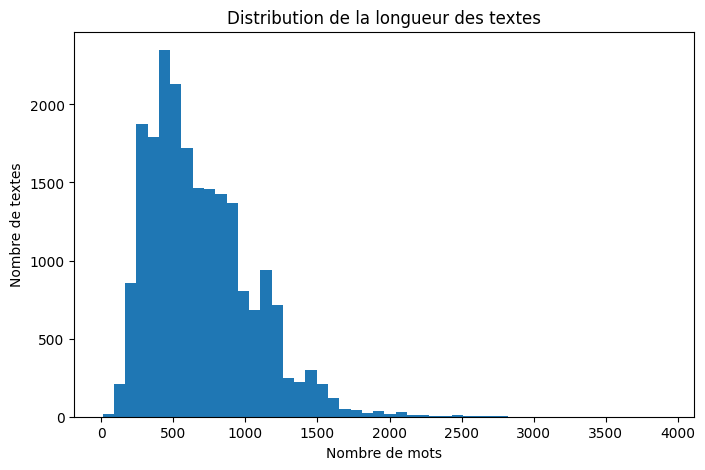

In [60]:
plt.figure(figsize=(8, 5))
plt.hist(df["n_words_raw"], bins=50)
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de textes")
plt.title("Distribution de la longueur des textes")
plt.show()

In [61]:
STOPWORDS = [x.strip() for x in open('data/stop_word_fr_pol.txt').readlines()]

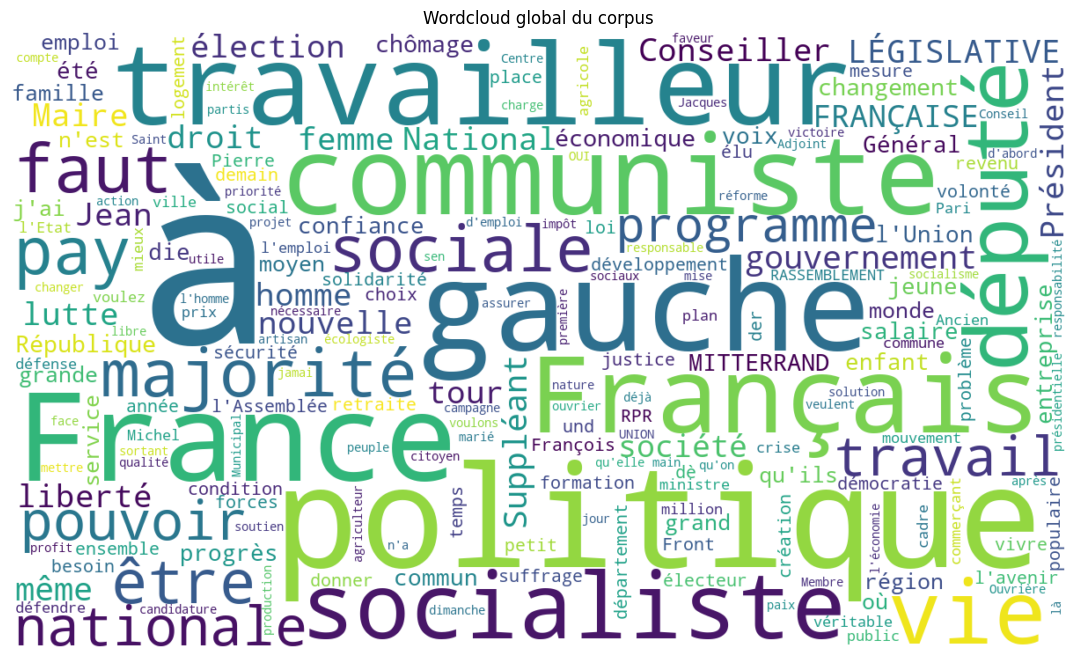

In [62]:
all_text = " ".join(df["text"])

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    stopwords=STOPWORDS,
    max_words=200,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud global du corpus")
plt.show()

In [63]:
count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=list(STOPWORDS),
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÖØ-öø-ÿ][a-zA-ZÀ-ÖØ-öø-ÿ'-]{2,}\b",
    max_features=5000,
    min_df=2
)

X_counts = count_vectorizer.fit_transform(df["text"])
terms = count_vectorizer.get_feature_names_out()

word_counts = np.asarray(X_counts.sum(axis=0)).ravel()

freq_df = pd.DataFrame({
    "term": terms,
    "count": word_counts
}).sort_values("count", ascending=False)

freq_df.head(50)

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celle-lã', 'celles-lã', 'celui-lã', 'celã', 'cembre', 'ceux-lã', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'elle-', 'elles-', 'eux-', 'exceptã', 'faã', 'gislatives', 'holã', 'huitiã', 'lections', 'lui-', 'majoritã', 'malgrã', 'mement', 'moi-', 'neuviã', 'nommã', 'nous-', 'ohã', 'ollã', 'olã', 'onziã', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quant-ã', 'quatriã', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'soi-', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'toi-', 'tre', 'troisiã', 'trã', 'voilã', 'votã', 'vous-', 'vrier'] not in stop_words.
  warnings.warn(


,term,count
3377,politique,43029
1923,gauche,39968
1856,france,37665
4598,travailleurs,30682
1864,français,29498
4741,vie,26956
2760,majorité,25580
1741,faut,25236
3272,pays,24768
4591,travail,21364


In [64]:
bigram_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=list(STOPWORDS),
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÖØ-öø-ÿ][a-zA-ZÀ-ÖØ-öø-ÿ'-]{2,}\b",
    ngram_range=(2, 2),
    max_features=5000,
    min_df=2
)

X_bigrams = bigram_vectorizer.fit_transform(df["text"])
bigram_terms = bigram_vectorizer.get_feature_names_out()

bigram_counts = np.asarray(X_bigrams.sum(axis=0)).ravel()

bigram_freq_df = pd.DataFrame({
    "bigram": bigram_terms,
    "count": bigram_counts
}).sort_values("count", ascending=False)

bigram_freq_df.head(50)

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celle-lã', 'celles-lã', 'celui-lã', 'celã', 'cembre', 'ceux-lã', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'elle-', 'elles-', 'eux-', 'exceptã', 'faã', 'gislatives', 'holã', 'huitiã', 'lections', 'lui-', 'majoritã', 'malgrã', 'mement', 'moi-', 'neuviã', 'nommã', 'nous-', 'ohã', 'ollã', 'olã', 'onziã', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quant-ã', 'quatriã', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'soi-', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'toi-', 'tre', 'troisiã', 'trã', 'voilã', 'votã', 'vous-', 'vrier'] not in stop_words.
  warnings.warn(


,bigram,count
4914,élections législatives,10063
3445,programme commun,9620
2102,l'assemblée nationale,7907
1635,front national,7205
669,conseiller général,6720
1621,françois mitterrand,6637
588,communiste français,5199
3989,république française,5044
670,conseiller municipal,4861
3581,président république,4753
